In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
import pickle

2026-03-12 11:20:02.405332: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773314402.625590      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773314402.686920      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773314403.213698      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773314403.213760      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773314403.213763      17 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path="/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages"

cat_path=os.path.join(dataset_path,"Cat")
dog_path=os.path.join(dataset_path,"Dog")

In [3]:
IMG_SIZE=128

data=[]
labels=[]

for file in os.listdir(cat_path):
    try:
        img_path=os.path.join(cat_path,file)
        img=cv2.imread(img_path)
        if img is None:
            continue
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(0)
    except:
        pass

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


In [4]:
IMG_SIZE=128

for file in os.listdir(dog_path):
    try:
        img_path=os.path.join(dog_path,file)
        img=cv2.imread(img_path)
        if img is None:
            continue
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(1)
    except:
        pass

Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 399 extraneous bytes before marker 0xd9


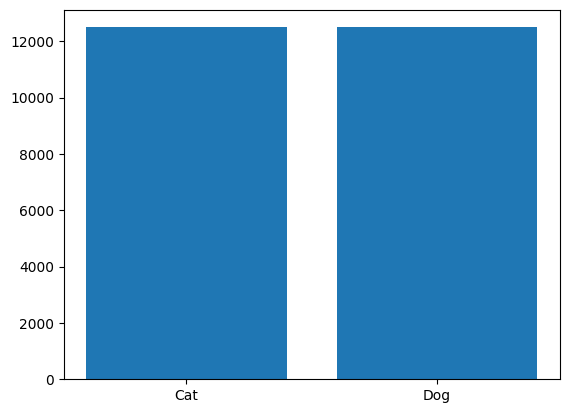

In [5]:
unique, counts=np.unique(labels,return_counts=True)

plt.bar(["Cat","Dog"],counts)
plt.show()

Text(0.5, 1.0, 'Image')

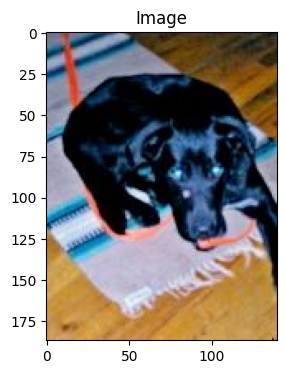

In [6]:
img = cv2.imread(img_path)

plt.figure(figsize = (8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Image")

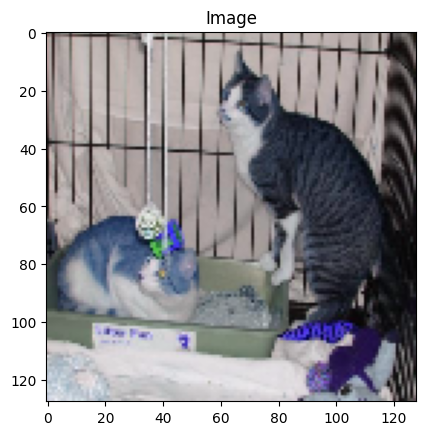

In [7]:
plt.imshow(data[0])
plt.title("Image")
plt.show()

In [8]:
#storing data and labels into arrays so that they can be evaluated
data=np.array(data)/255.0 #normalizing so that all the pixels are in the range of 0 to 1
labels=np.array(labels)

print("Data shape: ",data.shape)
print("Labels shape: ",labels.shape)

Data shape:  (24997, 128, 128, 3)
Labels shape:  (24997,)


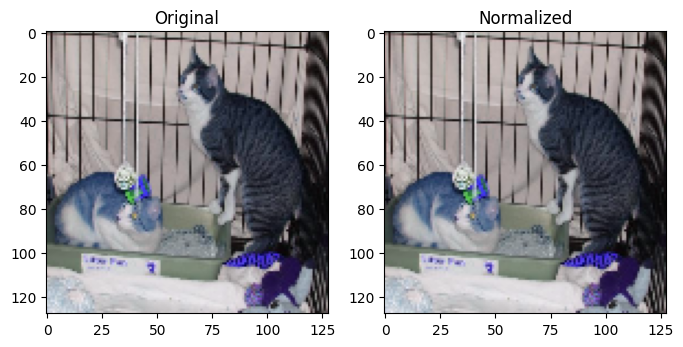

In [9]:
img=data[0]*255
normalized_img=data[0]
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img.astype('uint8'))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(normalized_img)
plt.title("Normalized")

plt.show()